## Preparation

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split
import pandas as pd
import pickle
import sys
import math
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
!{sys.executable} -m pip install -q "pyarrow>=13.0.0"

df = pd.read_pickle(
    r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\Datasets\harmonized_data.pkl"
)

## Models

In [38]:
class CrossAttentionFusionModel(nn.Module):
    def __init__(self, gene_dim=978, chem_dim=1032, hidden_dim=32, num_tokens=4, num_heads=4, dropout=0.3):
        super().__init__()
        self.num_tokens = num_tokens
        self.hidden_dim = hidden_dim
        
        self.input_dropout_gene = nn.Dropout(0.2)
        self.input_dropout_chem = nn.Dropout(0.3)

        self.gene_encoder = nn.Sequential(
            nn.Linear(gene_dim, num_tokens * hidden_dim),
            nn.BatchNorm1d(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.drug_encoder = nn.Sequential(
            nn.Linear(chem_dim, num_tokens * hidden_dim),
            nn.BatchNorm1d(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm_gene = nn.LayerNorm(hidden_dim)
        self.norm_drug = nn.LayerNorm(hidden_dim)
        
        self.regressor = nn.Sequential(
            nn.Linear(num_tokens * hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    
    def forward(self, x_gene, x_drug):
        batch_size = x_gene.size(0)
        x_gene = self.input_dropout_gene(x_gene)
        x_drug = self.input_dropout_chem(x_drug)

        gene_tokens = self.gene_encoder(x_gene).view(batch_size, self.num_tokens, self.hidden_dim)
        drug_tokens = self.drug_encoder(x_drug).view(batch_size, self.num_tokens, self.hidden_dim)

        gene_attn_out, gene_attn_weights = self.cross_attn(
            query=gene_tokens, key=drug_tokens, value=drug_tokens
        )
        drug_attn_out, drug_attn_weights = self.cross_attn(
            query=drug_tokens, key=gene_tokens, value=gene_tokens
        )
        self.last_attn_weights = {
            "gene_to_drug": gene_attn_weights.detach().cpu().numpy(),
            "drug_to_gene": drug_attn_weights.detach().cpu().numpy(),
        }

        gene_context = self.norm_gene(gene_tokens + gene_attn_out)
        drug_context = self.norm_drug(drug_tokens + drug_attn_out)

        fused = torch.cat(
            [gene_context.view(batch_size, -1), drug_context.view(batch_size, -1)],
            dim=1
        )
        pred = self.regressor(fused)
        return pred.squeeze(1)

In [3]:
class AdvancedSelfAndCrossAttentionModel(nn.Module):
    def __init__(self, gene_dim=978, chem_dim=1032, hidden_dim=64, num_heads=4, num_tokens=8, dropout=0.3):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_tokens = num_tokens
        
        # encoder: Projizieren die flachen Features in eine Token-Sequenz (Batch, num_tokens, hidden_dim)
        self.gene_encoder = nn.Sequential(
            nn.Linear(gene_dim, num_tokens * hidden_dim),
            nn.LayerNorm(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.drug_encoder = nn.Sequential(
            nn.Linear(chem_dim, num_tokens * hidden_dim),
            nn.LayerNorm(num_tokens * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Positional Encoding (Optional, aber hilfreich, damit die Attention die Token-IDs unterscheiden kann)
        self.gene_pos = nn.Parameter(torch.randn(1, num_tokens, hidden_dim))
        self.drug_pos = nn.Parameter(torch.randn(1, num_tokens, hidden_dim))

        # 2. SELF-ATTENTION: Jede Modalität kommuniziert erst mit sich selbst
        self.gene_self_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.drug_self_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        
        self.norm_self_gene = nn.LayerNorm(hidden_dim)
        self.norm_self_drug = nn.LayerNorm(hidden_dim)

        # 3. CROSS-ATTENTION: Chemie fragt Biologie ab
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm_cross = nn.LayerNorm(hidden_dim)

        # 4. REGRESSION HEAD
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_gene, x_drug):
        batch_size = x_gene.size(0)

        # --- Schritt 1: In Tokens transformieren ---
        # Shape: (B, num_tokens, hidden_dim)
        gene_tokens = self.gene_encoder(x_gene).view(batch_size, self.num_tokens, self.hidden_dim)
        drug_tokens = self.drug_encoder(x_drug).view(batch_size, self.num_tokens, self.hidden_dim)
        
        # Positional Embedding addieren
        gene_tokens = gene_tokens + self.gene_pos
        drug_tokens = drug_tokens + self.drug_pos

        # --- Schritt 2: Echte Self-Attention (Intra-modal) ---
        # Biologie filtert eigenes Rauschen
        gene_self_out, _ = self.gene_self_attn(query=gene_tokens, key=gene_tokens, value=gene_tokens)
        gene_tokens = self.norm_self_gene(gene_tokens + gene_self_out)

        # Chemie ordnet funktionelle Gruppen aneinander an
        drug_self_out, _ = self.drug_self_attn(query=drug_tokens, key=drug_tokens, value=drug_tokens)
        drug_tokens = self.norm_self_drug(drug_tokens + drug_self_out)

        # --- Schritt 3: Cross-Attention (Inter-modal) ---
        # Chemie (Query) greift auf biologischen Kontext (Key/Value) zu
        cross_out, _ = self.cross_attn(query=drug_tokens, key=gene_tokens, value=gene_tokens)
        drug_context = self.norm_cross(drug_tokens + cross_out)

        # --- Schritt 4: Pooling & Fusion ---
        # Wir mitteln über die Token-Dimension (Mean Pooling)
        gene_repr = gene_tokens.mean(dim=1)  # Shape: (B, hidden_dim)
        drug_repr = drug_context.mean(dim=1) # Shape: (B, hidden_dim)

        # Konkatenerieren zu (B, hidden_dim * 2)
        fused = torch.cat([gene_repr, drug_repr], dim=1)

        # Vorhersage
        pred = self.regressor(fused)
        return pred.squeeze(1)

Der DataLoader kümmert sich darum, dass das Modell die Daten in Batches bekommt

## Training data

In [35]:
# training data group split in train val
target = 'LN_IC50'
pharmacophores = ['Donor', 'Acceptor', 'Aromatic', 'Hydrophobe', 'LumpedHydrophobe', 'PosIonizable', 'NegIonizable', 'ZnBinder']
mfp_cols = [col for col in df.columns if col.startswith('Bit_')]
X_genomic = df.filter(regex=r'.* \(.*\)').values.astype('float32')
X_chem = df[pharmacophores + mfp_cols]
y = df[target].values.astype('float32')

# split data into train and test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=6726)
idx_train_val, idx_test = next(gss_test.split(X_genomic, y, groups=df['DRUG_ID']))

# separate validation set from training set
groups_train_val = df['DRUG_ID'].iloc[idx_train_val]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.11, random_state=42)
idx_train, idx_val = next(gss_val.split(X_genomic[idx_train_val], y[idx_train_val], groups=groups_train_val))

idx_train = idx_train_val[idx_train]
idx_val = idx_train_val[idx_val]

preprocessor = ColumnTransformer(
    transformers=[
        ('pharmacophore', StandardScaler(), pharmacophores),
        #('mfp', PCA(n_components=50, random_state=42), mfp_cols)
        ('mfp', 'passthrough', mfp_cols)
    ],
    remainder='drop'
)
gene_scaler = StandardScaler()

X_genomic_train = gene_scaler.fit_transform(X_genomic[idx_train])
X_chem_train = preprocessor.fit_transform(X_chem.iloc[idx_train])

X_genomic_val = gene_scaler.transform(X_genomic[idx_val])
X_chem_val = preprocessor.transform(X_chem.iloc[idx_val])

X_genomic_test = gene_scaler.transform(X_genomic[idx_test])
X_chem_test = preprocessor.transform(X_chem.iloc[idx_test])

# scale IC50 values
#scaler = StandardScaler()
y_train = y[idx_train]#scaler.fit_transform(y[idx_train].reshape(-1, 1)).flatten()
y_val = y[idx_val]#scaler.transform(y[idx_val].reshape(-1, 1)).flatten()
y_test = y[idx_test]#scaler.transform(y[idx_test].reshape(-1, 1)).flatten()

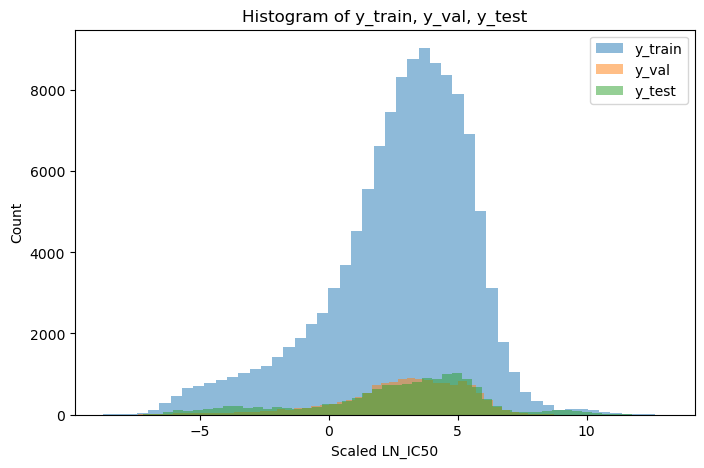

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y_train, bins=50, alpha=0.5, label='y_train')
plt.hist(y_val, bins=50, alpha=0.5, label='y_val')
plt.hist(y_test, bins=50, alpha=0.5, label='y_test')
plt.xlabel('Scaled LN_IC50')
plt.ylabel('Count')
plt.title('Histogram of y_train, y_val, y_test')
plt.legend()
plt.show()

In [42]:
class DrugResponseDataset(Dataset):
    def __init__(self, X_gen, X_ch, labels):
        self.X_genomic = torch.tensor(X_gen, dtype=torch.float32)
        self.X_chem = torch.tensor(X_ch if isinstance(X_ch, np.ndarray) else X_ch.values, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): 
        return len(self.y)
        
    def __getitem__(self, idx): 
        return self.X_genomic[idx], self.X_chem[idx], self.y[idx]
    
train_loader = DataLoader(DrugResponseDataset(X_genomic_train, X_chem_train, y_train), batch_size=128, shuffle=True, drop_last=True)
val_loader = DataLoader(DrugResponseDataset(X_genomic_val, X_chem_val, y_val), batch_size=128, shuffle=False)
test_loader = DataLoader(DrugResponseDataset(X_genomic_test, X_chem_test, y_test), batch_size=128, shuffle=False)

## Running 

Hier ist mein bestes Ergebnis bis jetzt, jedoch kann ich es nicht rekreieren...

In [28]:
# created by copilot
hidden_dim = 32
dropout = 0.3
lr = 1e-3
patience = 6
epochs = 20
weight_decay = 1e-2
num_tokens = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrossAttentionFusionModel(
    gene_dim=X_genomic.shape[1],
    chem_dim=X_chem_train.shape[1],
    hidden_dim=hidden_dim,
    num_heads=4,
    dropout=dropout,
    num_tokens=num_tokens
).to(device)

criterion = nn.MSELoss()
#optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=patience
)

best_val_rmse = float("inf")
best_val_r2 = None
best_epoch = -1

print("Start Training")
for epoch in range(epochs):
    model.train()
    train_preds, train_targets = [], []
    train_loss = 0.0

    for batch_genes, batch_chem, batch_y in train_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_genes, batch_chem).view(-1)
        batch_y = batch_y.view(-1)

        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_genes.size(0)
        train_preds.extend(predictions.detach().cpu().numpy())
        train_targets.extend(batch_y.detach().cpu().numpy())

    total_train_loss = train_loss / len(train_loader.dataset)
    train_preds_orig = np.array(train_preds)
    train_targets_orig = np.array(train_targets)
    train_rmse_orig = root_mean_squared_error(train_targets_orig, train_preds_orig)

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0.0

    with torch.no_grad():
        for batch_genes, batch_chem, batch_y in val_loader:
            batch_genes = batch_genes.to(device)
            batch_chem = batch_chem.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_genes, batch_chem).view(-1)
            loss = criterion(predictions, batch_y.view(-1))

            val_loss += loss.item() * batch_genes.size(0)
            val_preds.extend(predictions.cpu().numpy())
            val_targets.extend(batch_y.cpu().numpy())

    total_val_loss = val_loss / len(val_loader.dataset)
    val_preds = np.array(val_preds)
    val_targets = np.array(val_targets)
    val_rmse = root_mean_squared_error(val_targets, val_preds)
    val_r2 = r2_score(val_targets, val_preds)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_val_r2 = val_r2
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pt")

    scheduler.step(total_val_loss)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train RMSE: {train_rmse_orig:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R²: {val_r2:.4f}"
    )

model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for batch_genes, batch_chem, batch_y in test_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        predictions = model(batch_genes, batch_chem).view(-1)
        test_preds.extend(predictions.cpu().numpy())
        test_targets.extend(batch_y.cpu().numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

test_rmse = root_mean_squared_error(test_targets, test_preds)
test_r2 = r2_score(test_targets, test_preds)

print(f"Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")
print(
    f"Best model in epoch {best_epoch} with Val RMSE: {best_val_rmse:.4f} "
    f"and Val R²: {best_val_r2:.4f}"
)

Start Training
Epoch 01/20 | Train RMSE: 1.8199 | Val RMSE: 2.7299 | Val R²: -0.2054
Epoch 02/20 | Train RMSE: 1.5514 | Val RMSE: 2.7871 | Val R²: -0.2564
Epoch 03/20 | Train RMSE: 1.4996 | Val RMSE: 2.6893 | Val R²: -0.1698
Epoch 04/20 | Train RMSE: 1.4748 | Val RMSE: 2.5983 | Val R²: -0.0920
Epoch 05/20 | Train RMSE: 1.4642 | Val RMSE: 2.4693 | Val R²: 0.0138
Epoch 06/20 | Train RMSE: 1.4510 | Val RMSE: 2.6585 | Val R²: -0.1432
Epoch 07/20 | Train RMSE: 1.4362 | Val RMSE: 2.4020 | Val R²: 0.0667
Epoch 08/20 | Train RMSE: 1.4327 | Val RMSE: 2.6108 | Val R²: -0.1025
Epoch 09/20 | Train RMSE: 1.4289 | Val RMSE: 2.4752 | Val R²: 0.0090
Epoch 10/20 | Train RMSE: 1.4178 | Val RMSE: 2.5068 | Val R²: -0.0164
Epoch 11/20 | Train RMSE: 1.4169 | Val RMSE: 2.5994 | Val R²: -0.0930
Epoch 12/20 | Train RMSE: 1.4139 | Val RMSE: 2.6552 | Val R²: -0.1403
Epoch 13/20 | Train RMSE: 1.4097 | Val RMSE: 2.5695 | Val R²: -0.0680
Epoch 14/20 | Train RMSE: 1.4017 | Val RMSE: 2.3963 | Val R²: 0.0712
Epoch 15/

In [44]:
# created by copilot
hidden_dim = 32
dropout = 0.4
lr = 1e-3
patience = 6
epochs = 20
weight_decay = 1e-2
num_tokens = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrossAttentionFusionModel(
    gene_dim=X_genomic.shape[1],
    chem_dim=X_chem_train.shape[1],
    hidden_dim=hidden_dim,
    num_heads=4,
    dropout=dropout,
    num_tokens=num_tokens
).to(device)

criterion = nn.MSELoss()
#optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=patience
)

best_val_rmse = float("inf")
best_val_r2 = None
best_epoch = -1

print("Start Training")
for epoch in range(epochs):
    model.train()
    train_preds, train_targets = [], []
    train_loss = 0.0

    for batch_genes, batch_chem, batch_y in train_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_genes, batch_chem).view(-1)
        batch_y = batch_y.view(-1)

        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_genes.size(0)
        train_preds.extend(predictions.detach().cpu().numpy())
        train_targets.extend(batch_y.detach().cpu().numpy())

    total_train_loss = train_loss / len(train_loader.dataset)
    train_preds_orig = np.array(train_preds)
    train_targets_orig = np.array(train_targets)
    train_rmse_orig = root_mean_squared_error(train_targets_orig, train_preds_orig)

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0.0

    with torch.no_grad():
        for batch_genes, batch_chem, batch_y in val_loader:
            batch_genes = batch_genes.to(device)
            batch_chem = batch_chem.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_genes, batch_chem).view(-1)
            loss = criterion(predictions, batch_y.view(-1))

            val_loss += loss.item() * batch_genes.size(0)
            val_preds.extend(predictions.cpu().numpy())
            val_targets.extend(batch_y.cpu().numpy())

    total_val_loss = val_loss / len(val_loader.dataset)
    val_preds = np.array(val_preds)
    val_targets = np.array(val_targets)
    val_rmse = root_mean_squared_error(val_targets, val_preds)
    val_r2 = r2_score(val_targets, val_preds)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_val_r2 = val_r2
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pt")

    scheduler.step(total_val_loss)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train RMSE: {train_rmse_orig:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R²: {val_r2:.4f}"
    )

model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for batch_genes, batch_chem, batch_y in test_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        predictions = model(batch_genes, batch_chem).view(-1)
        test_preds.extend(predictions.cpu().numpy())
        test_targets.extend(batch_y.cpu().numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

test_rmse = root_mean_squared_error(test_targets, test_preds)
test_r2 = r2_score(test_targets, test_preds)

print(f"Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")
print(
    f"Best model in epoch {best_epoch} with Val RMSE: {best_val_rmse:.4f} "
    f"and Val R²: {best_val_r2:.4f}"
)

Start Training
Epoch 01/20 | Train RMSE: 1.9087 | Val RMSE: 2.6005 | Val R²: -0.0939
Epoch 02/20 | Train RMSE: 1.6568 | Val RMSE: 2.7631 | Val R²: -0.2349
Epoch 03/20 | Train RMSE: 1.6045 | Val RMSE: 2.6376 | Val R²: -0.1253
Epoch 04/20 | Train RMSE: 1.5779 | Val RMSE: 2.7491 | Val R²: -0.2224
Epoch 05/20 | Train RMSE: 1.5605 | Val RMSE: 2.6630 | Val R²: -0.1471
Epoch 06/20 | Train RMSE: 1.5440 | Val RMSE: 2.4547 | Val R²: 0.0254
Epoch 07/20 | Train RMSE: 1.5334 | Val RMSE: 2.5154 | Val R²: -0.0234
Epoch 08/20 | Train RMSE: 1.5239 | Val RMSE: 2.5566 | Val R²: -0.0572
Epoch 09/20 | Train RMSE: 1.5170 | Val RMSE: 2.6806 | Val R²: -0.1623
Epoch 10/20 | Train RMSE: 1.5153 | Val RMSE: 2.4831 | Val R²: 0.0027
Epoch 11/20 | Train RMSE: 1.5023 | Val RMSE: 2.4092 | Val R²: 0.0612
Epoch 12/20 | Train RMSE: 1.5036 | Val RMSE: 2.5414 | Val R²: -0.0447
Epoch 13/20 | Train RMSE: 1.5002 | Val RMSE: 2.5543 | Val R²: -0.0553
Epoch 14/20 | Train RMSE: 1.5012 | Val RMSE: 2.4668 | Val R²: 0.0158
Epoch 15/

In [45]:
# created by copilot
hidden_dim = 32
dropout = 0.4
lr = 1e-3
patience = 6
epochs = 20
weight_decay = 1e-2
num_tokens = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrossAttentionFusionModel(
    gene_dim=X_genomic.shape[1],
    chem_dim=X_chem_train.shape[1],
    hidden_dim=hidden_dim,
    num_heads=4,
    dropout=dropout,
    num_tokens=num_tokens
).to(device)

criterion = nn.MSELoss()
#optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=patience
)

best_val_rmse = float("inf")
best_val_r2 = None
best_epoch = -1

print("Start Training")
for epoch in range(epochs):
    model.train()
    train_preds, train_targets = [], []
    train_loss = 0.0

    for batch_genes, batch_chem, batch_y in train_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_genes, batch_chem).view(-1)
        batch_y = batch_y.view(-1)

        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_genes.size(0)
        train_preds.extend(predictions.detach().cpu().numpy())
        train_targets.extend(batch_y.detach().cpu().numpy())

    total_train_loss = train_loss / len(train_loader.dataset)
    train_preds_orig = np.array(train_preds)
    train_targets_orig = np.array(train_targets)
    train_rmse_orig = root_mean_squared_error(train_targets_orig, train_preds_orig)

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0.0

    with torch.no_grad():
        for batch_genes, batch_chem, batch_y in val_loader:
            batch_genes = batch_genes.to(device)
            batch_chem = batch_chem.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_genes, batch_chem).view(-1)
            loss = criterion(predictions, batch_y.view(-1))

            val_loss += loss.item() * batch_genes.size(0)
            val_preds.extend(predictions.cpu().numpy())
            val_targets.extend(batch_y.cpu().numpy())

    total_val_loss = val_loss / len(val_loader.dataset)
    val_preds = np.array(val_preds)
    val_targets = np.array(val_targets)
    val_rmse = root_mean_squared_error(val_targets, val_preds)
    val_r2 = r2_score(val_targets, val_preds)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_val_r2 = val_r2
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pt")

    scheduler.step(total_val_loss)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train RMSE: {train_rmse_orig:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R²: {val_r2:.4f}"
    )

model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for batch_genes, batch_chem, batch_y in test_loader:
        batch_genes = batch_genes.to(device)
        batch_chem = batch_chem.to(device)
        batch_y = batch_y.to(device)

        predictions = model(batch_genes, batch_chem).view(-1)
        test_preds.extend(predictions.cpu().numpy())
        test_targets.extend(batch_y.cpu().numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

test_rmse = root_mean_squared_error(test_targets, test_preds)
test_r2 = r2_score(test_targets, test_preds)

print(f"Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")
print(
    f"Best model in epoch {best_epoch} with Val RMSE: {best_val_rmse:.4f} "
    f"and Val R²: {best_val_r2:.4f}"
)

Start Training
Epoch 01/20 | Train RMSE: 1.9394 | Val RMSE: 2.6149 | Val R²: -0.1060
Epoch 02/20 | Train RMSE: 1.6848 | Val RMSE: 2.6578 | Val R²: -0.1426
Epoch 03/20 | Train RMSE: 1.6430 | Val RMSE: 2.8784 | Val R²: -0.3401
Epoch 04/20 | Train RMSE: 1.6089 | Val RMSE: 2.8044 | Val R²: -0.2721
Epoch 05/20 | Train RMSE: 1.5782 | Val RMSE: 2.8299 | Val R²: -0.2953
Epoch 06/20 | Train RMSE: 1.5662 | Val RMSE: 2.7809 | Val R²: -0.2509
Epoch 07/20 | Train RMSE: 1.5614 | Val RMSE: 2.4321 | Val R²: 0.0432
Epoch 08/20 | Train RMSE: 1.5482 | Val RMSE: 2.5450 | Val R²: -0.0477
Epoch 09/20 | Train RMSE: 1.5443 | Val RMSE: 2.5769 | Val R²: -0.0741
Epoch 10/20 | Train RMSE: 1.5347 | Val RMSE: 2.3977 | Val R²: 0.0701
Epoch 11/20 | Train RMSE: 1.5339 | Val RMSE: 2.4518 | Val R²: 0.0277
Epoch 12/20 | Train RMSE: 1.5270 | Val RMSE: 2.5542 | Val R²: -0.0552
Epoch 13/20 | Train RMSE: 1.5271 | Val RMSE: 2.4298 | Val R²: 0.0450
Epoch 14/20 | Train RMSE: 1.5207 | Val RMSE: 2.5558 | Val R²: -0.0565
Epoch 15/

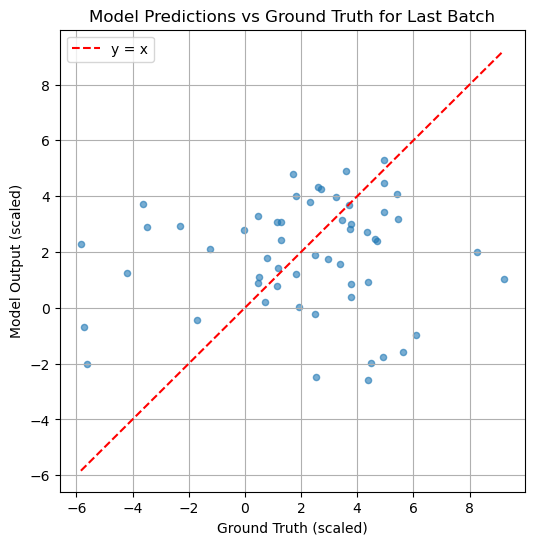

In [21]:
preds = predictions.detach().cpu().numpy()
targets = batch_y.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(targets, preds, alpha=0.6, s=20)
lims = [min(targets.min(), preds.min()), max(targets.max(), preds.max())]
plt.plot(lims, lims, 'r--', label='y = x')
plt.xlabel('Ground Truth (scaled)')
plt.ylabel('Model Output (scaled)')
plt.title('Model Predictions vs Ground Truth for Last Batch')
plt.legend()
plt.grid(True)
plt.show()